# LeetCode Algorithmic Tag Classifier

Multi-label classification of LeetCode problems into algorithmic tags (e.g. `array`, `dynamic-programming`, `tree`) directly from the problem description, using fine-tuned transformer models.

**What this notebook does:**
- Fine-tunes and compares two transformer model, **DeBERTa-v3** and **CodeBERT**, on multi-label tag prediction across 63 possible tags
- Diagnoses why the models get things wrong via per-tag F1, tag co-occurrence, and false-positive analysis
- Investigates whether code-pretraining (CodeBERT) helps despite a smaller max token length than DeBERTa

**Dataset:** [`newfacade/LeetCodeDataset`](https://huggingface.co/datasets/newfacade/LeetCodeDataset) via Hugging Face `datasets`

**GPU:** Originally done on Google Colab, used A100 GPU or better

In [ ]:
# Setup - install dependencies
!pip install -q datasets transformers scikit-learn seaborn matplotlib torch

import os
os.makedirs('checkpoints', exist_ok=True)  # local dir for saved model weights

In [ ]:
from datasets import load_dataset
ds = load_dataset("newfacade/LeetCodeDataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/665 [00:00<?, ?B/s]

LeetCodeDataset-train.jsonl:   0%|          | 0.00/93.6M [00:00<?, ?B/s]

LeetCodeDataset-test.jsonl:   0%|          | 0.00/7.46M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2641 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/228 [00:00<?, ? examples/s]

Using the given train/test split from the dataset, which is about 90/10, instead of 80/20.
Final split is ~80/10/10 for train, validation, and test.

In [ ]:
train_val = ds['train'].train_test_split(test_size=0.1, seed=123)

train_data = train_val['train']
val_data = train_val['test']
test_data = ds['test']

print(train_data[0])  # first example
# print(train_data[0]['problem_description'])
print(train_data[0]['tags'])
print()
print(f"train: {train_data.shape}")
print(f"val: {val_data.shape}")
print(f"test: {test_data.shape}")

{'task_id': 'search-in-rotated-sorted-array-ii', 'question_id': 81, 'difficulty': 'Medium', 'tags': ['Array', 'Binary Search'], 'problem_description': 'There is an integer array nums sorted in non-decreasing order (not necessarily with distinct values).\nBefore being passed to your function, nums is rotated at an unknown pivot index k (0 <= k < nums.length) such that the resulting array is [nums[k], nums[k+1], ..., nums[n-1], nums[0], nums[1], ..., nums[k-1]] (0-indexed). For example, [0,1,2,4,4,4,5,6,6,7] might be rotated at pivot index 5 and become [4,5,6,6,7,0,1,2,4,4].\nGiven the array nums after the rotation and an integer target, return true if target is in nums, or false if it is not in nums.\nYou must decrease the overall operation steps as much as possible.\n\xa0\nExample 1:\nInput: nums = [2,5,6,0,0,1,2], target = 0\nOutput: true\nExample 2:\nInput: nums = [2,5,6,0,0,1,2], target = 3\nOutput: false\n\n\xa0\nConstraints:\n\n1 <= nums.length <= 5000\n-104 <= nums[i] <= 104\nnum

In [ ]:
# want to check problems that exceed 512 tokens (roberta limit)

from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

count = 0
# check token lengths across all training examples
for i, text in enumerate(train_data['problem_description']):
    tokens = tokenizer(text)['input_ids']
    if len(tokens) > 512:
      count += 1

print(count)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (518 > 512). Running this sequence through the model will result in indexing errors


399


Originally was going to use RoBERTa, but saw that a sizeable amount of our train data (~400/2600) has > 512 tokens (limit for RoBERTa, so we would need to truncate). For the sake of trying to get as many tokens as we can (better model), we are using a different model of BERT, called DeBERTa (also good for classification). For our experiment, we'll try using CodeBERT and compare it to DeBERTa, and see if one has an advantage over the other (CodeBERT is learned off of natural language and programming language, so might be able to perform better even with smaller token limit).

In [ ]:
# want to check problems that exceed 1024 tokens (deberta limit)

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-base')

count = 0
# check token lengths across all training examples
for i, text in enumerate(train_data['problem_description']):
    tokens = tokenizer(text)['input_ids']
    if len(tokens) > 1024:
      count += 1
      truncated = tokenizer.decode(tokens[1024:])
      print(f"truncated ({len(tokens) - 1024} tokens)")
      print(truncated)
      print()

print(f"total: {count}")
# now we should only have 3 problems with > 1024 tokens, these will be truncated

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

truncated (78 tokens)
The rook is attacking the pawns at positions b5, d6, and f5. Constraints: board.length == 8 board[i].length == 8 board[i][j] is either 'R', '.', 'B', or 'p' There is exactly one cell with board[i][j] == 'R'

truncated (549 tokens)
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0] Output: [1.00000,4.00000,2.18182,2.00000,1.00000] Explanation: The sample represented by count is [1,1,1,1,2,2,2,3,3,4,4]. The minimum and maximum are 1 and 4 respectively. The mean is (1+1+1+1+2+2+2+3+3+4+4) / 11 = 24 / 11 = 2.18181818... (for display purposes, the output shows the rounded number 2.18182). Since the size of the sample is odd, the median is the middle element 2. The mode

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

print(train_data[:5]['tags'])
mlb = MultiLabelBinarizer()

tags = train_data[:]['tags']

binary_matrix = mlb.fit_transform(tags)
print("Binary Matrix:\n", binary_matrix)
print("\nClass Order:\n", mlb.classes_)
print(f"labels: {len(mlb.classes_)}") # 63

[['Array', 'Binary Search'], ['Bit Manipulation', 'Depth-First Search', 'Breadth-First Search'], ['Array', 'Heap (Priority Queue)'], ['Tree', 'Depth-First Search', 'Breadth-First Search', 'Array', 'Hash Table', 'String'], ['Tree', 'Depth-First Search', 'Graph', 'Dynamic Programming']]
Binary Matrix:
 [[1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Class Order:
 ['Array' 'Backtracking' 'Biconnected Component' 'Binary Indexed Tree'
 'Binary Search' 'Binary Search Tree' 'Binary Tree' 'Bit Manipulation'
 'Bitmask' 'Brainteaser' 'Breadth-First Search' 'Bucket Sort'
 'Combinatorics' 'Concurrency' 'Counting' 'Counting Sort'
 'Depth-First Search' 'Divide and Conquer' 'Dynamic Programming'
 'Enumeration' 'Eulerian Circuit' 'Game Theory' 'Geometry' 'Graph'
 'Greedy' 'Hash Function' 'Hash Table' 'Heap (Priority Queue)'
 'Interactive' 'Line Sweep' 'Linked List' 'Math' 'Matrix' 'Memoization'
 'Merge Sort' 'Minimum Spanning Tre

In [ ]:
# multi-hot vector representations of all training, val, test samples
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

mlb = MultiLabelBinarizer()

train_labels = mlb.fit_transform(train_data[:]['tags']).astype(np.float32)
val_labels = mlb.transform(val_data[:]['tags']).astype(np.float32)
test_labels = mlb.transform(test_data[:]['tags']).astype(np.float32)

In [ ]:
# this is just doing the tokenization of problem descriptions,
# and putting that data into corresponding datasets to be used for training

from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset, DataLoader

class LeetCodeDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         torch.tensor(self.labels[idx], dtype=torch.float)
        }

class LeetCodeDataModule:
    def __init__(self, train_data, val_data, test_data,
                 train_labels, val_labels, test_labels,
                 model_name='microsoft/deberta-v3-base',
                 batch_size=16,
                 max_length=1024):

        self.model_name = model_name
        self.batch_size = batch_size
        self.max_length = max_length

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        train_encodings = self._tokenize(train_data['problem_description'])
        val_encodings = self._tokenize(val_data['problem_description'])
        test_encodings = self._tokenize(test_data['problem_description'])

        self.train_dataset = LeetCodeDataset(train_encodings, train_labels)
        self.val_dataset   = LeetCodeDataset(val_encodings, val_labels)
        self.test_dataset  = LeetCodeDataset(test_encodings, test_labels)

    def _tokenize(self, texts):
        return self.tokenizer(
            list(texts),
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )

    def train_loader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_loader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_loader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

In [ ]:
# DeBERTa
deberta_dm = LeetCodeDataModule(
    train_data, val_data, test_data,
    train_labels, val_labels, test_labels,
    model_name='microsoft/deberta-v3-base',
    batch_size=8,
    max_length=1024 # deberta token limit
)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [ ]:
# model setup, have a save and load so we can keep best model for later if needed

from transformers import AutoModelForSequenceClassification
import torch

class LeetCodeModel:
    def __init__(self, model_name, num_labels, device=None, l_rate=2e-5):
        self.model_name = model_name
        self.num_labels = num_labels
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')

        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_labels,
            problem_type="multi_label_classification"
        ).to(self.device)

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=l_rate)

    def save(self, path):
        torch.save(self.model.state_dict(), path)

    def load(self, path):
        self.model.load_state_dict(torch.load(path))

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

num_labels = len(mlb.classes_) # 63

# DeBERTa
deberta_model = LeetCodeModel(
    model_name='microsoft/deberta-v3-base',
    num_labels=num_labels,
    device=device,
    l_rate=2e-5
)
deberta_model.model = deberta_model.model.float()

Using device: cuda


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier

In [ ]:
# train the models, save best one

from sklearn.metrics import f1_score
import numpy as np

def train(model_wrapper, data_module, num_epochs=5, save_path='best_model.pt'):
    device = model_wrapper.device
    model = model_wrapper.model
    optimizer = model_wrapper.optimizer

    train_loader = data_module.train_loader()
    val_loader   = data_module.val_loader()

    best_val_f1 = 0

    train_losses = []
    val_losses = []
    val_f1s = []

    for epoch in range(num_epochs):
        # training
        model.train()
        total_train_loss = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # validation
        model.eval()
        total_val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                total_val_loss += outputs.loss.item()

                preds = torch.sigmoid(outputs.logits) > 0.5
                all_preds.append(preds.cpu().numpy())
                all_labels.append(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        all_preds = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)

        val_micro_f1 = f1_score(all_labels, all_preds, average='micro', zero_division=0)
        val_macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        val_f1s.append(val_micro_f1)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val Micro F1: {val_micro_f1:.4f} | "
              f"Val Macro F1: {val_macro_f1:.4f}")

        # save best model based on validation micro F1
        if val_micro_f1 > best_val_f1:
            best_val_f1 = val_micro_f1
            model_wrapper.save(save_path)
            print(f"saved best model (Val Micro F1: {val_micro_f1:.4f})")

    return {
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'val_f1s':      val_f1s
    }

In [ ]:
# DeBERTa
deberta_history = train(
    deberta_model,
    deberta_dm,
    num_epochs=6,
    save_path='checkpoints/deberta_best.pt'
)

Epoch 1/6 | Train Loss: 0.2316 | Val Loss: 0.1341 | Val Micro F1: 0.4055 | Val Macro F1: 0.0295
saved best model (Val Micro F1: 0.4055)
Epoch 2/6 | Train Loss: 0.1350 | Val Loss: 0.1199 | Val Micro F1: 0.5000 | Val Macro F1: 0.0773
saved best model (Val Micro F1: 0.5000)
Epoch 3/6 | Train Loss: 0.1227 | Val Loss: 0.1161 | Val Micro F1: 0.5129 | Val Macro F1: 0.0868
saved best model (Val Micro F1: 0.5129)
Epoch 4/6 | Train Loss: 0.1173 | Val Loss: 0.1108 | Val Micro F1: 0.5290 | Val Macro F1: 0.0954
saved best model (Val Micro F1: 0.5290)
Epoch 5/6 | Train Loss: 0.1141 | Val Loss: 0.1102 | Val Micro F1: 0.5387 | Val Macro F1: 0.1079
saved best model (Val Micro F1: 0.5387)
Epoch 6/6 | Train Loss: 0.1104 | Val Loss: 0.1111 | Val Micro F1: 0.5399 | Val Macro F1: 0.1201
saved best model (Val Micro F1: 0.5399)


In [ ]:
# DeBERTa
deberta_history2 = train(
    deberta_model,
    deberta_dm,
    num_epochs=4,
    save_path='checkpoints/deberta_best.pt'
)

Epoch 1/4 | Train Loss: 0.1074 | Val Loss: 0.1081 | Val Micro F1: 0.5534 | Val Macro F1: 0.1290
saved best model (Val Micro F1: 0.5534)
Epoch 2/4 | Train Loss: 0.1047 | Val Loss: 0.1092 | Val Micro F1: 0.5535 | Val Macro F1: 0.1244
saved best model (Val Micro F1: 0.5535)
Epoch 3/4 | Train Loss: 0.1022 | Val Loss: 0.1088 | Val Micro F1: 0.5459 | Val Macro F1: 0.1244
Epoch 4/4 | Train Loss: 0.0991 | Val Loss: 0.1061 | Val Micro F1: 0.5671 | Val Macro F1: 0.1369
saved best model (Val Micro F1: 0.5671)


In [ ]:
print(f"Memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"Memory reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")

In [ ]:
# CodeBERT
codebert_dm = LeetCodeDataModule(
    train_data, val_data, test_data,
    train_labels, val_labels, test_labels,
    model_name='microsoft/codebert-base',
    batch_size=8,
    max_length=512 # codebert token limit
)

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
# CodeBERT
codebert_model = LeetCodeModel(
    model_name='microsoft/codebert-base',
    num_labels=num_labels,
    device=device,
    l_rate=2e-5
)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# CodeBERT
codebert_history = train(
    codebert_model,
    codebert_dm,
    num_epochs=5,
    save_path='checkpoints/codebert_best.pt'
)

Epoch 1/5 | Train Loss: 0.1891 | Val Loss: 0.1481 | Val Micro F1: 0.2957 | Val Macro F1: 0.0126
saved best model (Val Micro F1: 0.2957)
Epoch 2/5 | Train Loss: 0.1435 | Val Loss: 0.1259 | Val Micro F1: 0.4269 | Val Macro F1: 0.0440
saved best model (Val Micro F1: 0.4269)
Epoch 3/5 | Train Loss: 0.1264 | Val Loss: 0.1160 | Val Micro F1: 0.5252 | Val Macro F1: 0.0904
saved best model (Val Micro F1: 0.5252)
Epoch 4/5 | Train Loss: 0.1177 | Val Loss: 0.1117 | Val Micro F1: 0.5411 | Val Macro F1: 0.1063
saved best model (Val Micro F1: 0.5411)
Epoch 5/5 | Train Loss: 0.1116 | Val Loss: 0.1084 | Val Micro F1: 0.5405 | Val Macro F1: 0.1072


In [ ]:
codebert_history2 = train(
    codebert_model,
    codebert_dm,
    num_epochs=5,
    save_path='checkpoints/codebert_best.pt'
)

Epoch 1/5 | Train Loss: 0.1058 | Val Loss: 0.1052 | Val Micro F1: 0.5562 | Val Macro F1: 0.1163
saved best model (Val Micro F1: 0.5562)
Epoch 2/5 | Train Loss: 0.1003 | Val Loss: 0.1011 | Val Micro F1: 0.5816 | Val Macro F1: 0.1453
saved best model (Val Micro F1: 0.5816)
Epoch 3/5 | Train Loss: 0.0939 | Val Loss: 0.1016 | Val Micro F1: 0.5826 | Val Macro F1: 0.1494
saved best model (Val Micro F1: 0.5826)
Epoch 4/5 | Train Loss: 0.0877 | Val Loss: 0.0981 | Val Micro F1: 0.6059 | Val Macro F1: 0.1621
saved best model (Val Micro F1: 0.6059)
Epoch 5/5 | Train Loss: 0.0805 | Val Loss: 0.0972 | Val Micro F1: 0.6091 | Val Macro F1: 0.1694
saved best model (Val Micro F1: 0.6091)


In [ ]:
from sklearn.metrics import f1_score

def evaluate(model_wrapper, data_module, model_path):
    device = model_wrapper.device
    model = model_wrapper.model
    model_wrapper.load(model_path)
    model.eval()

    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in data_module.test_loader():
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.sigmoid(outputs.logits) > 0.5

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    micro_f1 = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    per_tag_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

    print(f"Test Micro F1: {micro_f1:.4f}")
    print(f"Test Macro F1: {macro_f1:.4f}")

    return {
      'micro_f1':   micro_f1,
      'macro_f1':   macro_f1,
      'per_tag_f1': per_tag_f1,
      'preds':      all_preds,
      'labels':     all_labels
    }

Final test scores for DeBERTa model, saved best model within 15 epochs

In [ ]:
# evaluate DeBERTa on test set
deberta_results = evaluate(
    deberta_model,
    deberta_dm,
    model_path='checkpoints/deberta_best.pt'
)

Test Micro F1: 0.5056
Test Macro F1: 0.1135


Final test scores for CodeBERT model, saved best model within 15 epochs

In [ ]:
# evaluate CodeBERT on test set
codebert_results = evaluate(
    codebert_model,
    codebert_dm,
    model_path='checkpoints/codebert_best.pt'
)

Test Micro F1: 0.5591
Test Macro F1: 0.1512


In [ ]:
print("model comparison")
print(f"{'Model':<12} {'Micro F1':<12} {'Macro F1':<12}")
print(f"{'DeBERTa':<12} {deberta_results['micro_f1']:<12.4f} {deberta_results['macro_f1']:<12.4f}")
print(f"{'CodeBERT':<12} {codebert_results['micro_f1']:<12.4f} {codebert_results['macro_f1']:<12.4f}")

model comparison
Model        Micro F1     Macro F1    
DeBERTa      0.5056       0.1135      
CodeBERT     0.5591       0.1512      


In [ ]:
# combine histories
deberta_train_losses = deberta_history['train_losses'] + deberta_history2['train_losses']
deberta_val_losses   = deberta_history['val_losses'] + deberta_history2['val_losses']
deberta_val_f1s      = deberta_history['val_f1s'] + deberta_history2['val_f1s']

codebert_train_losses = codebert_history['train_losses'] + codebert_history2['train_losses']
codebert_val_losses   = codebert_history['val_losses'] + codebert_history2['val_losses']
codebert_val_f1s      = codebert_history['val_f1s'] + codebert_history2['val_f1s']

In [ ]:
import json

history = {
    "deberta": {
        "train_losses": deberta_train_losses,
        "val_losses": deberta_val_losses,
        "val_f1s": deberta_val_f1s,
    },
    "codebert": {
        "train_losses": codebert_train_losses,
        "val_losses": codebert_val_losses,
        "val_f1s": codebert_val_f1s,
    },
}

with open("training_history.json", "w") as f:
    json.dump(history, f)

# RESULTS

dont really have explanation for most of these, but hopefully they are mostly self-explanatory, both models trained on 10 epochs

things to note:
- DeBERTa used the full 1024 tokens when tokenizing problem descriptions, which only meant 3 training samples were truncated.
- CodeBERT use 512 tokens when tokenizing, which meant around 382 training samples were truncated.

In [ ]:
tag_counts = test_labels.sum(axis=0)
print(f"\nTags with 0 test examples: {(tag_counts == 0).sum()} / {len(mlb.classes_)}")
print(f"Tags with test examples: {(tag_counts > 0).sum()} / {len(mlb.classes_)}")


Tags with 0 test examples: 18 / 63
Tags with test examples: 45 / 63


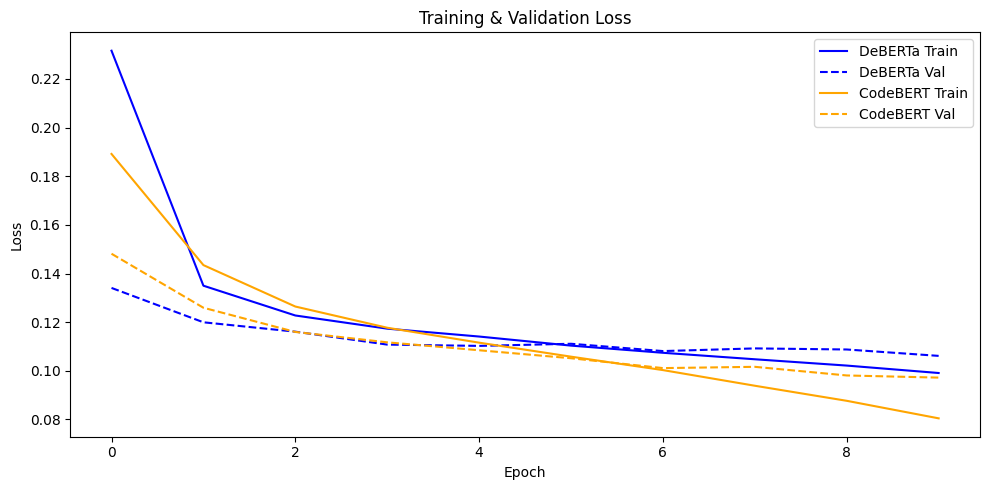

In [ ]:
# Plot 1 - Training & Validation Loss
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(deberta_train_losses,  label='DeBERTa Train',  color='blue')
plt.plot(deberta_val_losses,    label='DeBERTa Val',    color='blue',   linestyle='--')
plt.plot(codebert_train_losses, label='CodeBERT Train', color='orange')
plt.plot(codebert_val_losses,   label='CodeBERT Val',   color='orange', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

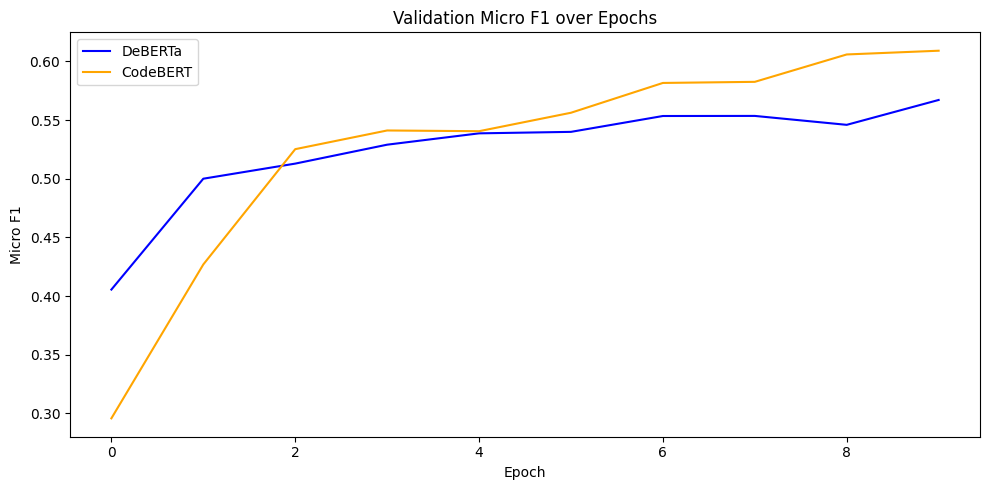

In [ ]:
# Plot 2 - Validation Micro F1
plt.figure(figsize=(10, 5))
plt.plot(deberta_val_f1s,  label='DeBERTa',  color='blue')
plt.plot(codebert_val_f1s, label='CodeBERT', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Micro F1')
plt.title('Validation Micro F1 over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

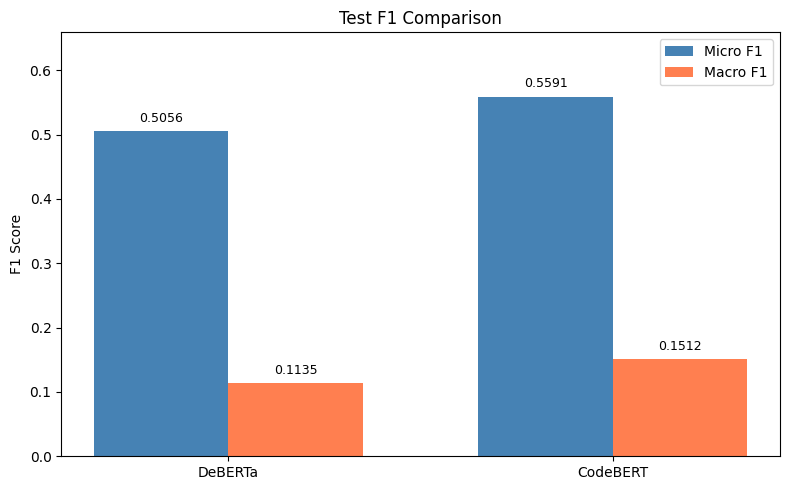

In [ ]:
# Plot 3 - Test F1 Comparison
models    = ['DeBERTa', 'CodeBERT']
micro_f1s = [deberta_results['micro_f1'], codebert_results['micro_f1']]
macro_f1s = [deberta_results['macro_f1'], codebert_results['macro_f1']]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, micro_f1s, width, label='Micro F1', color='steelblue')
bars2 = ax.bar(x + width/2, macro_f1s, width, label='Macro F1', color='coral')

# Add scores on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('F1 Score')
ax.set_title('Test F1 Comparison')
ax.legend()
ax.set_ylim(0, max(micro_f1s + macro_f1s) + 0.1)
plt.tight_layout()
plt.show()

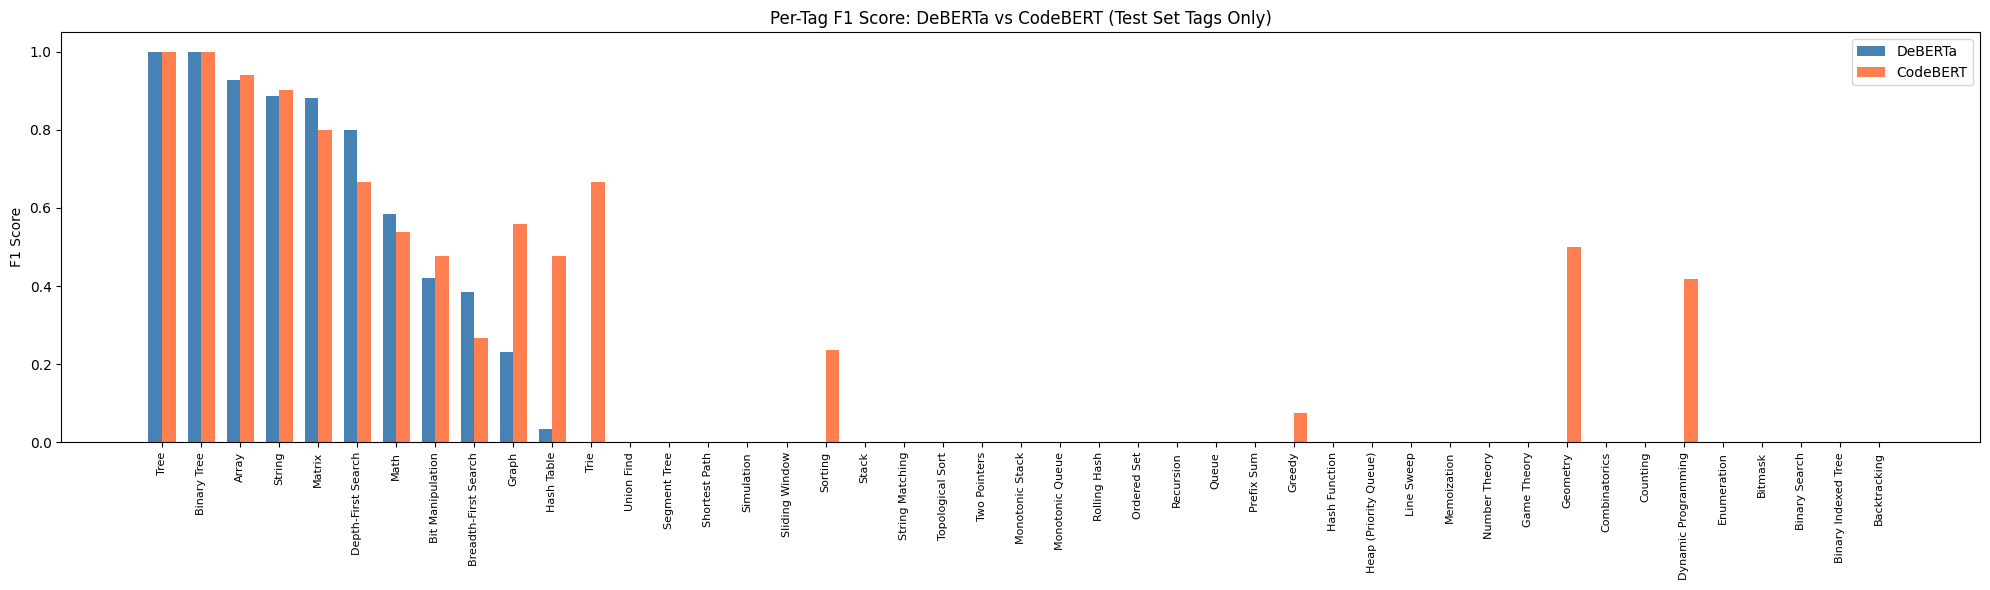

In [ ]:
# Find tags that appear at least once in test set
test_tag_counts = test_labels.sum(axis=0)
test_tag_mask = test_tag_counts > 0

# Filter to only tags present in test set
test_tags = mlb.classes_[test_tag_mask]
deberta_per_tag_filtered  = deberta_results['per_tag_f1'][test_tag_mask]
codebert_per_tag_filtered = codebert_results['per_tag_f1'][test_tag_mask]

# Sort by DeBERTa F1
sorted_indices   = deberta_per_tag_filtered.argsort()[::-1]
sorted_tags      = test_tags[sorted_indices]
deberta_sorted   = deberta_per_tag_filtered[sorted_indices]
codebert_sorted  = codebert_per_tag_filtered[sorted_indices]

# Plot
x     = np.arange(len(sorted_tags))
width = 0.35

plt.figure(figsize=(20, 6))
plt.bar(x - width/2, deberta_sorted,  width, label='DeBERTa',  color='steelblue')
plt.bar(x + width/2, codebert_sorted, width, label='CodeBERT', color='coral')
plt.xticks(x, sorted_tags, rotation=90, fontsize=8)
plt.ylabel('F1 Score')
plt.title('Per-Tag F1 Score: DeBERTa vs CodeBERT (Test Set Tags Only)')
plt.legend()
plt.tight_layout()
plt.show()

Tree has the largest f1 score, maybe shows that problems that are tagged 'tree' are very obviously tree due to how they are worded? can see big difference between codebert and deberta (so ig programming language training = better classification, over getting more tokens?)

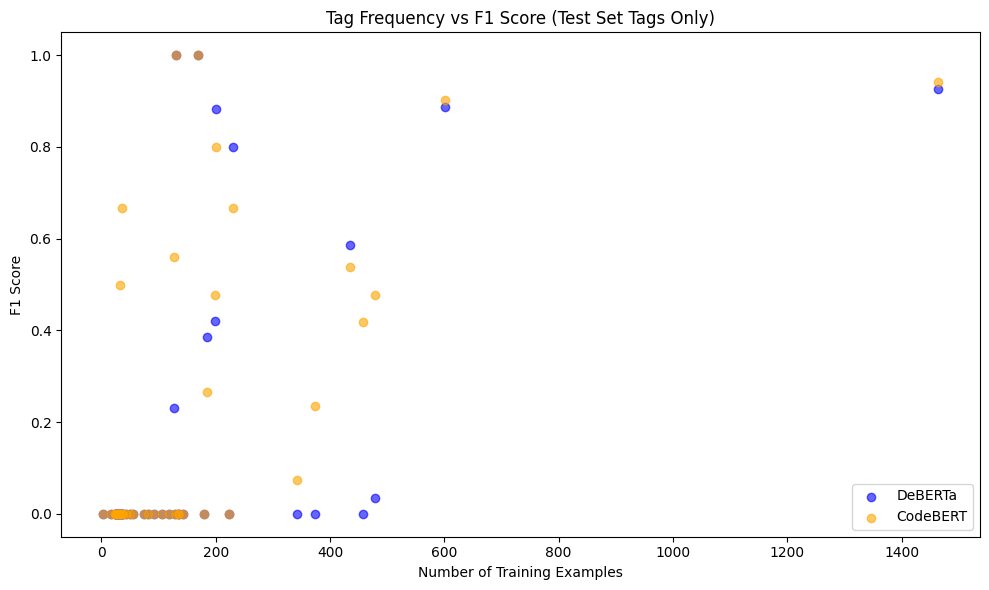

In [ ]:
# Filter to only tags present in test set
test_tag_counts = test_labels.sum(axis=0)
test_tag_mask = test_tag_counts > 0

# Filter all arrays to test tags only
test_tags             = mlb.classes_[test_tag_mask]
train_counts_filtered = train_labels.sum(axis=0)[test_tag_mask]
deberta_f1_filtered   = deberta_results['per_tag_f1'][test_tag_mask]
codebert_f1_filtered  = codebert_results['per_tag_f1'][test_tag_mask]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(train_counts_filtered, deberta_f1_filtered,  label='DeBERTa',  color='blue',   alpha=0.6)
plt.scatter(train_counts_filtered, codebert_f1_filtered, label='CodeBERT', color='orange', alpha=0.6)
plt.xlabel('Number of Training Examples')
plt.ylabel('F1 Score')
plt.title('Tag Frequency vs F1 Score (Test Set Tags Only)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
tag_counts = train_labels.sum(axis=0)
for i, (tag, count, f1) in enumerate(zip(mlb.classes_, tag_counts, deberta_results['per_tag_f1'])):
    if f1 > 0.95:
        print(f"{tag}: count={int(count)}, F1={f1:.4f}")

Binary Tree: count=130, F1=1.0000
Tree: count=169, F1=1.0000


Occurences of each tag within the training set

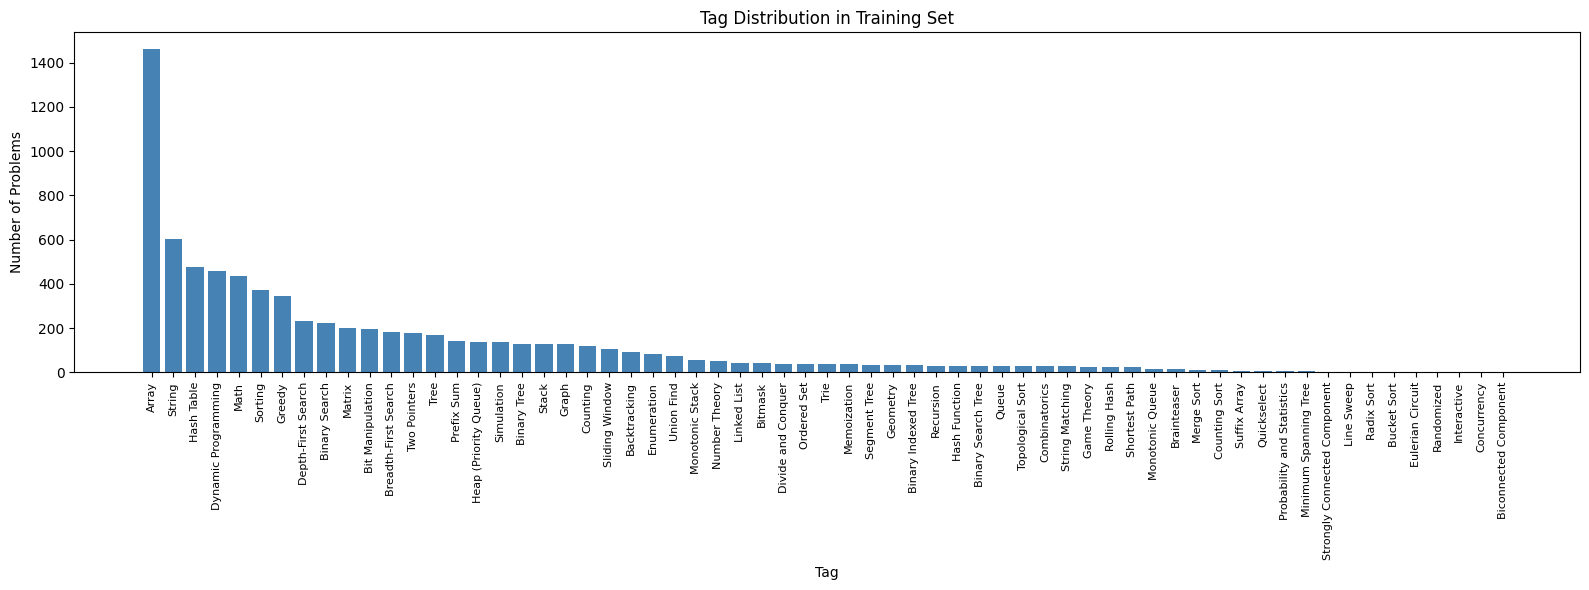


Tag counts (sorted):
  Array                               1464
  String                              602
  Hash Table                          478
  Dynamic Programming                 457
  Math                                435
  Sorting                             374
  Greedy                              343
  Depth-First Search                  231
  Binary Search                       224
  Matrix                              200
  Bit Manipulation                    198
  Breadth-First Search                184
  Two Pointers                        180
  Tree                                169
  Prefix Sum                          143
  Heap (Priority Queue)               136
  Simulation                          135
  Binary Tree                         130
  Stack                               129
  Graph                               127
  Counting                            118
  Sliding Window                      107
  Backtracking                        92
  Enumeratio

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Count occurrences of each tag in training set
tag_counts = train_labels.sum(axis=0)

# Sort by frequency
sorted_indices = tag_counts.argsort()[::-1]
sorted_counts  = tag_counts[sorted_indices]
sorted_tags    = mlb.classes_[sorted_indices]

# Plot
plt.figure(figsize=(16, 6))
bars = plt.bar(range(len(sorted_tags)), sorted_counts, color='steelblue')
plt.xticks(range(len(sorted_tags)), sorted_tags, rotation=90, fontsize=8)
plt.xlabel('Tag')
plt.ylabel('Number of Problems')
plt.title('Tag Distribution in Training Set')
plt.tight_layout()
plt.show()

# Also print the numbers
print("\nTag counts (sorted):")
for tag, count in zip(sorted_tags, sorted_counts):
    print(f"  {tag:<35} {int(count)}")

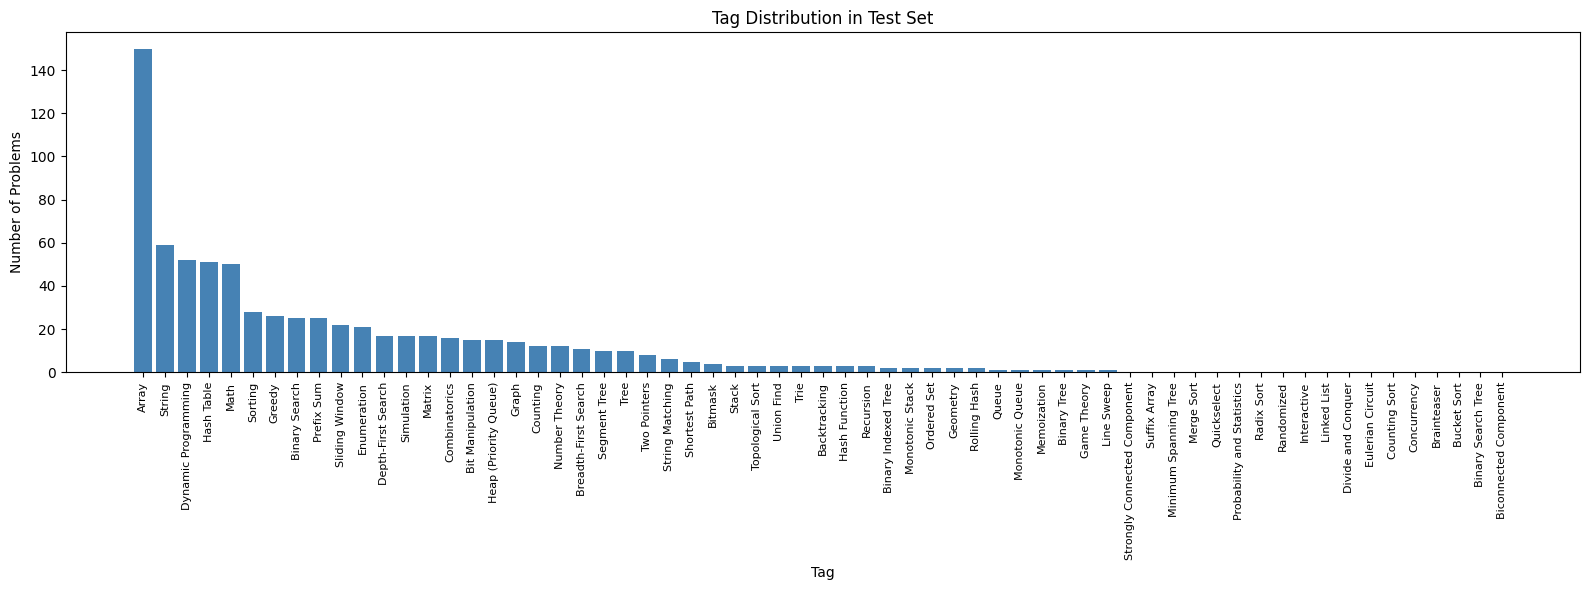


Tag counts (sorted):
  Array                               150
  String                              59
  Dynamic Programming                 52
  Hash Table                          51
  Math                                50
  Sorting                             28
  Greedy                              26
  Binary Search                       25
  Prefix Sum                          25
  Sliding Window                      22
  Enumeration                         21
  Depth-First Search                  17
  Simulation                          17
  Matrix                              17
  Combinatorics                       16
  Bit Manipulation                    15
  Heap (Priority Queue)               15
  Graph                               14
  Counting                            12
  Number Theory                       12
  Breadth-First Search                11
  Segment Tree                        10
  Tree                                10
  Two Pointers                    

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Count occurrences of each tag in test set
tag_counts = test_labels.sum(axis=0)

# Sort by frequency
sorted_indices = tag_counts.argsort()[::-1]
sorted_counts  = tag_counts[sorted_indices]
sorted_tags    = mlb.classes_[sorted_indices]

# Plot
plt.figure(figsize=(16, 6))
bars = plt.bar(range(len(sorted_tags)), sorted_counts, color='steelblue')
plt.xticks(range(len(sorted_tags)), sorted_tags, rotation=90, fontsize=8)
plt.xlabel('Tag')
plt.ylabel('Number of Problems')
plt.title('Tag Distribution in Test Set')
plt.tight_layout()
plt.show()

# Also print the numbers
print("\nTag counts (sorted):")
for tag, count in zip(sorted_tags, sorted_counts):
    print(f"  {tag:<35} {int(count)}")

Getting a co-occurence heatmap (seeing which tags are more likely to appear with another tag, in training set), might be useful to compare against results, since if our model sees for instance 'array' with 'hash table' many times, then during testing its more likely to see an 'array' problem and also label it as 'hash table', since there are many training samples of them together.

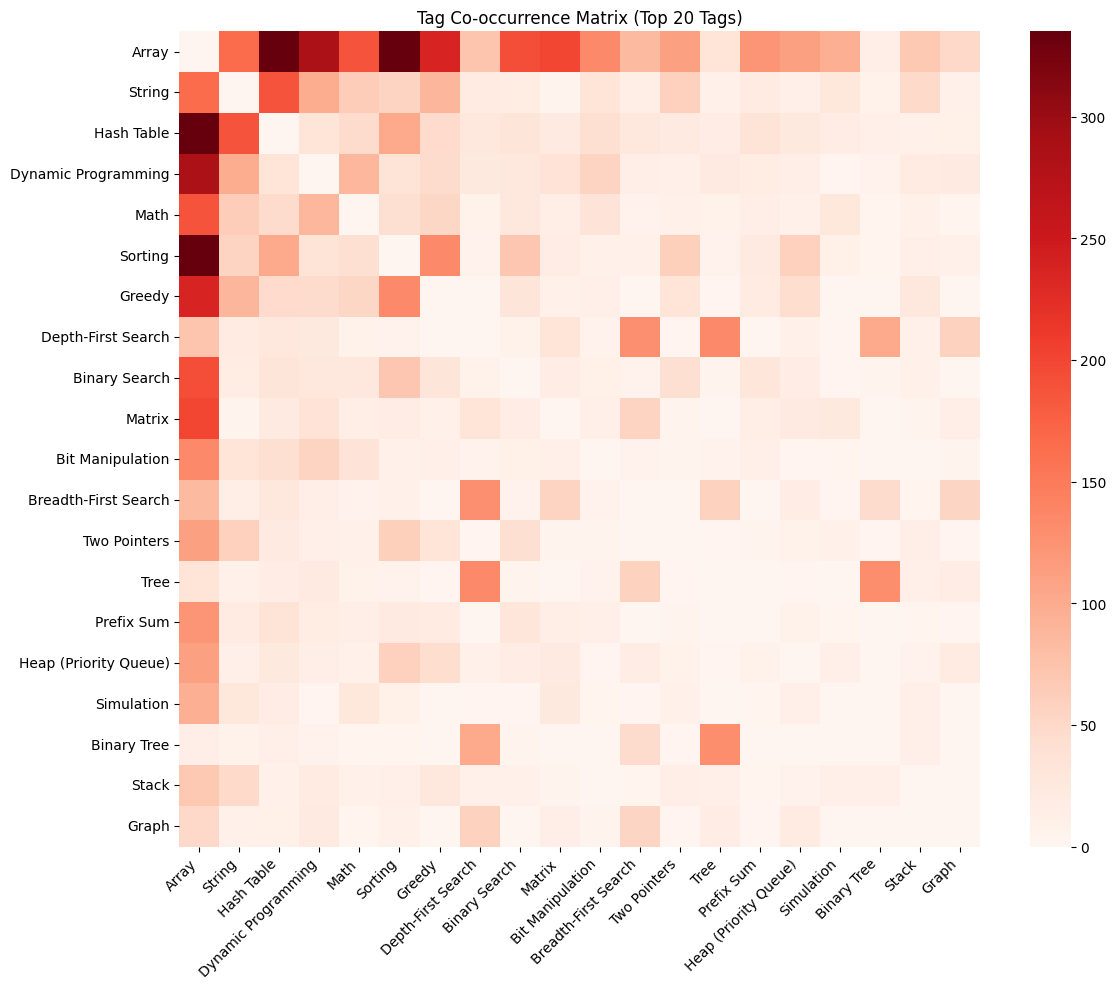

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

co_occurrence = train_labels.T @ train_labels

np.fill_diagonal(co_occurrence, 0)

tag_counts = train_labels.sum(axis=0)

######## CAN CHANGE THE VALUE '20' (for smaller/bigger matrix)
top_tag_num = 20
top_indices = tag_counts.argsort()[-top_tag_num:][::-1]
top_labels = mlb.classes_[top_indices]

co_sub = co_occurrence[np.ix_(top_indices, top_indices)]

plt.figure(figsize=(12, 10))
sns.heatmap(co_sub, xticklabels=top_labels, yticklabels=top_labels,
            cmap='Reds')
plt.xticks(rotation=45, ha='right')
plt.title(f'Tag Co-occurrence Matrix (Top {top_tag_num} Tags)')
plt.tight_layout()
plt.show()

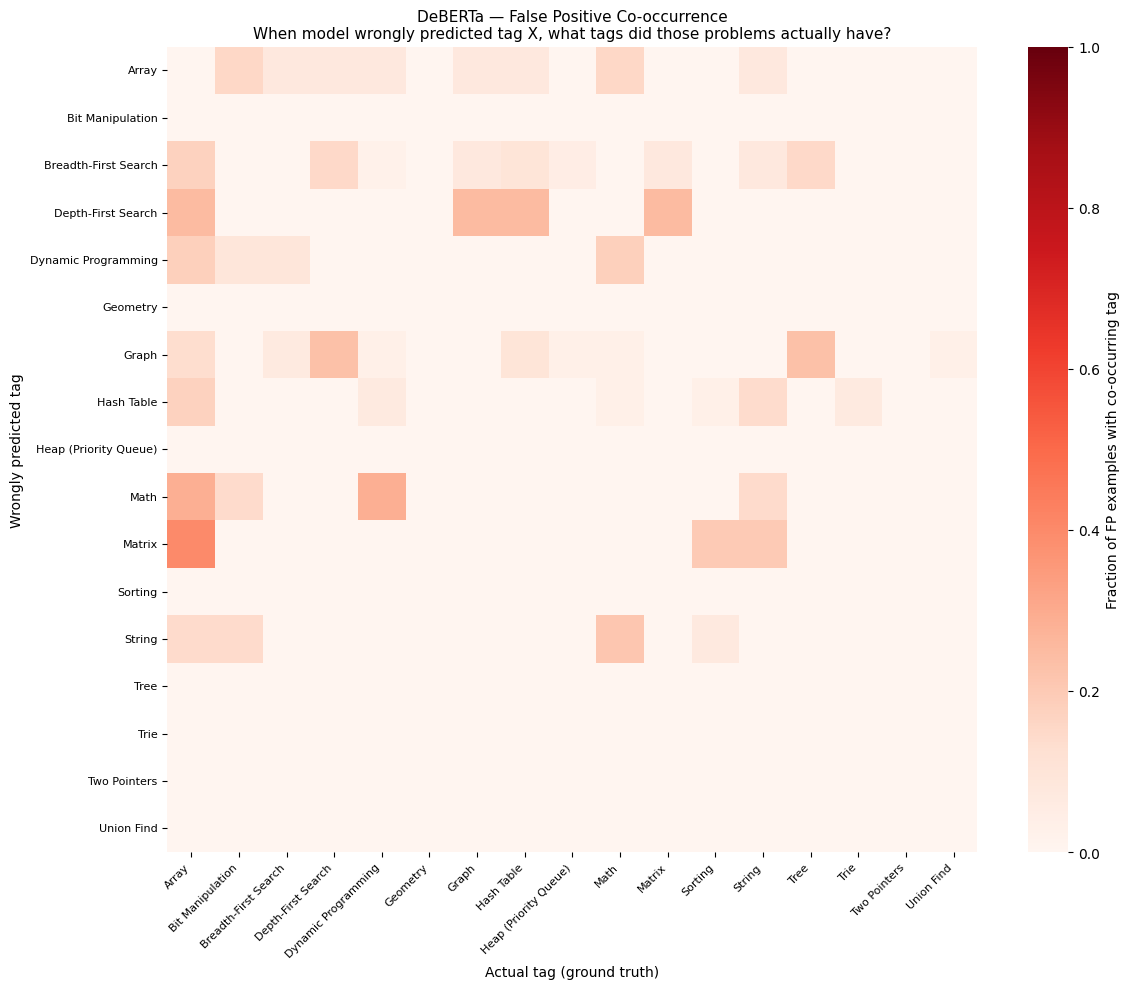

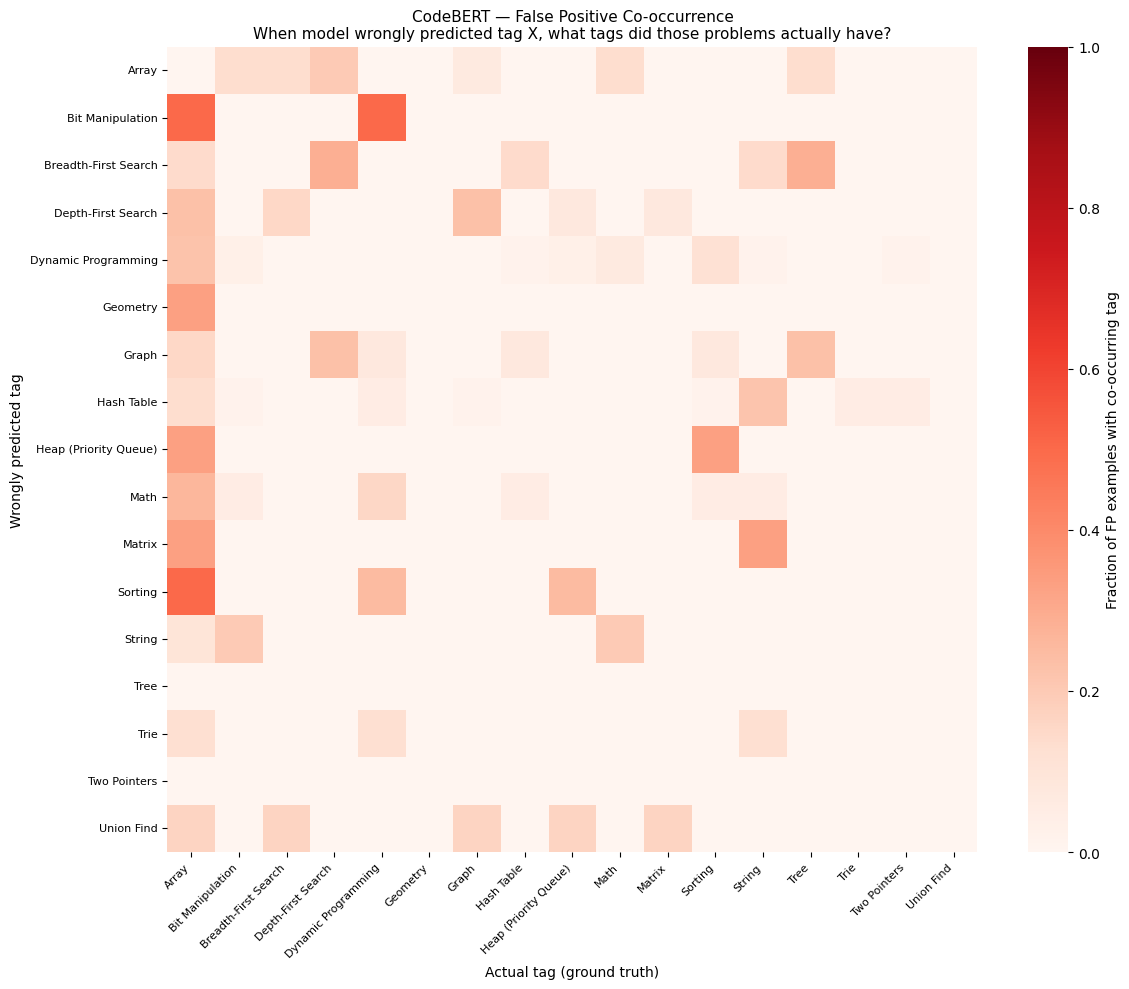

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def fp_cooccurrence(preds, labels):
    n_classes = labels.shape[1]
    cooc = np.zeros((n_classes, n_classes), dtype=float)

    for i in range(n_classes):
        error_mask = (labels[:, i] == 0) & (preds[:, i] == 1)
        if error_mask.sum() == 0:
            continue
        cooc[i] = labels[error_mask].sum(axis=0)
        cooc[i, i] = 0

    row_sums = cooc.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return cooc / row_sums


def get_active_tags(preds, labels, top_n=12):
    cooc = fp_cooccurrence(preds, labels)
    test_tag_counts = labels.sum(axis=0)
    has_test_examples = np.where(test_tag_counts > 0)[0]
    cooc_filtered = cooc[np.ix_(has_test_examples, has_test_examples)]
    active_local = np.argsort(cooc_filtered.sum(axis=1))[::-1][:top_n]
    return has_test_examples[active_local]


def plot_fp_cooc(preds, labels, class_names, model_name, active_tags):
    cooc = fp_cooccurrence(preds, labels)
    sub = cooc[np.ix_(active_tags, active_tags)]
    sub_names = class_names[active_tags]

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(sub, xticklabels=sub_names, yticklabels=sub_names,
                cmap='Reds', ax=ax, vmin=0, vmax=1,
                cbar_kws={'label': 'Fraction of FP examples with co-occurring tag'})
    ax.set_title(f'{model_name} — False Positive Co-occurrence\n'
                 f'When model wrongly predicted tag X, what tags did those problems actually have?',
                 fontsize=11)
    ax.set_xlabel('Actual tag (ground truth)')
    ax.set_ylabel('Wrongly predicted tag')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{model_name}_fp_cooccurrence.png', dpi=150, bbox_inches='tight')
    plt.show()


# Compute shared tag set
deberta_tags  = get_active_tags(deberta_results['preds'],  deberta_results['labels'])
codebert_tags = get_active_tags(codebert_results['preds'], codebert_results['labels'])
shared_tags = np.array(sorted(set(deberta_tags) | set(codebert_tags)))

# Plot separately, same shared tags
for model_name, preds, labels in [
    ('DeBERTa',  deberta_results['preds'],  deberta_results['labels']),
    ('CodeBERT', codebert_results['preds'], codebert_results['labels'])
]:
    plot_fp_cooc(preds, labels, mlb.classes_, model_name, shared_tags)